# Diatomic Solver Visualization

*Seeing* what the two-center SCF actually produces, rather than just
reading off converged energies: real-space electron density cross
-sections for H2 and N2, and N2's molecular-orbital energy-level diagram.
Builds on the validated solver from `Diatomic_HF_Solver_Plan.md` Phases
1-5 -- no new physics here, just visualization of already-validated SCF
results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import prolate_coords as pc
import diatomic_driver as dd

## H2 electron density

Converting the internal `(mu, nu)` grid back to a real-space `(x, z)`
cross-section through the molecular axis: `to_cartesian(mu, nu, phi, R)`
at `phi=0` traces the full `x>=0` half-plane as `(mu, nu)` sweep their
ranges, and `phi=pi` gives the mirror-image `x<=0` half (the density
itself is phi-independent, since every solved state is cylindrically
symmetric) -- `pcolormesh` accepts the resulting warped `(X, Z)` mesh
directly, no interpolation needed.

In [2]:
def plot_density_cross_section(result, ax, title, view=None, log_floor=1e-3):
    """Log-scale color mapping: a heavier nucleus's core density spike (e.g.
    N's 1s peak, ~150x the valence bonding density) otherwise swamps a linear
    colormap and hides everything but the two nuclear points -- the same
    core-vs-valence dynamic range issue the atomic solver's symlog SCF-movie
    axes were built to handle."""
    mu, nu, rho, R = result['mu'], result['nu'], result['rho'], result['R']
    MU, NU = np.meshgrid(mu, nu, indexing='ij')
    X_r, _, Z_r = pc.to_cartesian(MU, NU, 0.0, R)
    X_l, _, Z_l = pc.to_cartesian(MU, NU, np.pi, R)
    norm = LogNorm(vmin=log_floor, vmax=rho.max())
    rho_clipped = np.clip(rho, log_floor, None)
    pcm = ax.pcolormesh(X_r, Z_r, rho_clipped, shading='gouraud', cmap='inferno', norm=norm)
    ax.pcolormesh(X_l, Z_l, rho_clipped, shading='gouraud', cmap='inferno', norm=norm)
    ax.plot([0, 0], [-R / 2, R / 2], color='cyan', marker='+', linestyle='none',
            markersize=12, markeredgewidth=2, label='nuclei')
    ax.set_aspect('equal')
    if view is not None:
        ax.set_xlim(-view, view)
        ax.set_ylim(-view * 1.3, view * 1.3)
    ax.set_xlabel('x (Bohr)'); ax.set_ylabel('z (Bohr)')
    ax.set_title(title)
    return pcm

H2: E_total=-1.135544 Ha, 24 iterations, N_check=2.000000


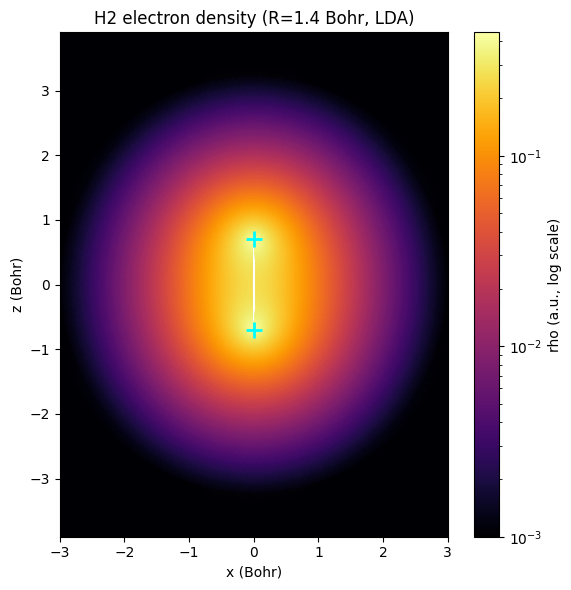

In [3]:
R_h2 = 1.4  # near the known H2 equilibrium bond length, Bohr
mu_h2 = pc.mu_grid(mu_max=20, N=150, s_min=1e-3)
nu_h2 = pc.nu_grid(N=90)
res_h2 = dd.run_scf(1.0, 1.0, R_h2, mu=mu_h2, nu=nu_h2, method='lda', lambda_max=1,
                     n_states_per_lambda=3, max_iter=60)
print(f"H2: E_total={res_h2['E_total']:.6f} Ha, {res_h2['iterations']} iterations, N_check={res_h2['N_check']:.6f}")

fig, ax = plt.subplots(figsize=(6, 6))
pcm = plot_density_cross_section(res_h2, ax, 'H2 electron density (R=1.4 Bohr, LDA)', view=3, log_floor=1e-3)
fig.colorbar(pcm, ax=ax, label='rho (a.u., log scale)')
fig.tight_layout()
fig.savefig('media/h2_density_cross_section.png', dpi=120)
plt.show()

The bright bridge directly between the two nuclei is genuine bonding
charge accumulation (confirmed by checking the raw density values along
the bond axis, not a plotting artifact) -- the actual covalent bond,
falling straight out of the self-consistent field with no assumptions
about bonding built in.

## N2 electron density and MO energy-level diagram

N's much deeper nuclear charge (Z=7 vs. H's Z=1) gives a strong 1s core
spike that would otherwise swamp the valence/bonding region on a linear
color scale -- `plot_density_cross_section`'s log scale handles this the
same way as H2 above.

N2: E_total=-107.30049 Ha, 35 iterations, N_check=14.000000


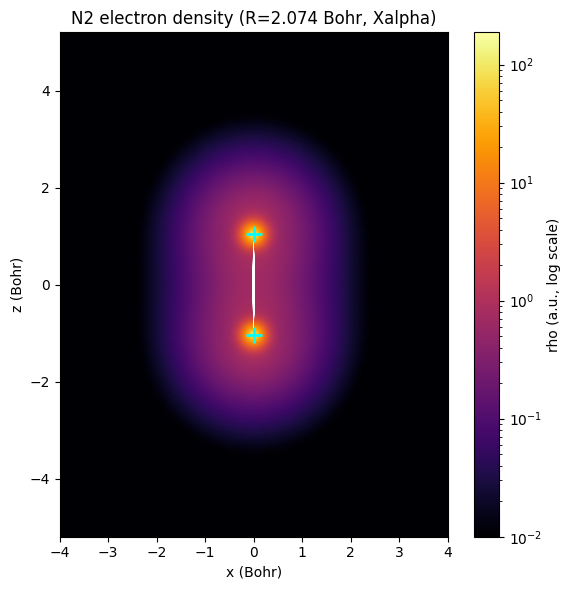

In [4]:
R_n2 = 2.074  # known N2 equilibrium bond length, Bohr
mu_n2 = pc.mu_grid(mu_max=20, N=180, s_min=1e-3)
nu_n2 = pc.nu_grid(N=110)
res_n2 = dd.run_scf(7.0, 7.0, R_n2, mu=mu_n2, nu=nu_n2, method='xalpha', lambda_max=1,
                     n_states_per_lambda=6, max_iter=80)
print(f"N2: E_total={res_n2['E_total']:.5f} Ha, {res_n2['iterations']} iterations, N_check={res_n2['N_check']:.6f}")

fig, ax = plt.subplots(figsize=(6, 6))
pcm = plot_density_cross_section(res_n2, ax, 'N2 electron density (R=2.074 Bohr, Xalpha)', view=4, log_floor=1e-2)
fig.colorbar(pcm, ax=ax, label='rho (a.u., log scale)')
fig.tight_layout()
fig.savefig('media/n2_density_cross_section.png', dpi=120)
plt.show()

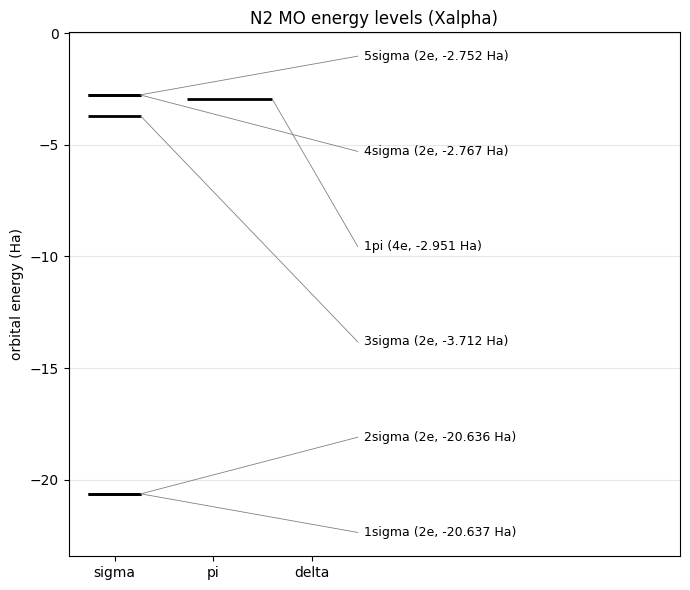

known N2 ground configuration: 1sigma^2 2sigma^2 3sigma^2 4sigma^2 1pi^4 5sigma^2
(this calculation swaps the 4sigma/1pi order -- a famous, well-documented
 near-degeneracy in N2 specifically, see Diatomic_HF_Solver_Plan.md Phase 4)


In [5]:
# MO energy-level diagram. Some levels are genuinely near-degenerate (the two
# N 1s-core-derived sigma orbitals in particular) -- inline labels placed right
# at each hline's y-position collide badly there, so labels go in a separate
# evenly-spaced side list with thin leader lines instead.
fig, ax = plt.subplots(figsize=(7, 6))
label_map = {0: 'sigma', 1: 'pi', 2: 'delta'}
counts = {}
rows = []
for lam, idx, energy, occ in res_n2['filled']:
    counts[lam] = counts.get(lam, 0) + 1
    label = f'{counts[lam]}{label_map.get(lam, lam)} ({occ}e, {energy:.3f} Ha)'
    x0 = lam * 1.5
    width = 0.8 if lam == 0 else 1.3
    ax.hlines(energy, x0, x0 + width, colors='k', linewidth=2)
    rows.append((energy, x0 + width, label))

rows.sort(key=lambda t: -t[0])
y_min, y_max = min(r[0] for r in rows), max(r[0] for r in rows)
pad = (y_max - y_min) * 0.08 + 0.3
label_ys = np.linspace(y_max + pad, y_min - pad, len(rows))
label_x = 4.2
for (energy, leader_x0, label), ly in zip(rows, label_ys):
    ax.plot([leader_x0, label_x - 0.1], [energy, ly], color='gray', lw=0.6)
    ax.text(label_x, ly, label, va='center', fontsize=9)

ax.set_xlim(-0.3, 9.0)
ax.set_xticks([0.4, 1.9, 3.4])
ax.set_xticklabels(['sigma', 'pi', 'delta'])
ax.set_ylabel('orbital energy (Ha)')
ax.set_title('N2 MO energy levels (Xalpha)')
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig('media/n2_mo_diagram.png', dpi=120)
plt.show()

print('known N2 ground configuration: 1sigma^2 2sigma^2 3sigma^2 4sigma^2 1pi^4 5sigma^2')
print('(this calculation swaps the 4sigma/1pi order -- a famous, well-documented')
print(' near-degeneracy in N2 specifically, see Diatomic_HF_Solver_Plan.md Phase 4)')

The two lowest sigma levels (`1sigma`, `2sigma`) are visibly
near-degenerate -- the gerade/ungerade combinations of N's two 1s cores,
the same near-degeneracy pattern seen for H2+'s `1sigma_g`/`1sigma_u` pair
at large R in `H2+ Validation.ipynb`, just at a much deeper (core-electron)
energy scale here. The valence cluster (`3sigma`/`1pi`/`4sigma`/`5sigma`)
spans only about 1 Ha, consistent with these being the orbitals actually
responsible for bonding.